# Case study : Dataset shift

In this notebook we implement the PSI Index on TSMC's stock price prediction through time. 

Let's start with the dataset itself :

In [3]:
import pandas as pd

df = pd.read_csv("TSM.csv")
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)
df.head()

,TSM,NVDA,MU,Gold,Silver,Platinium,Paladium,Copper
Date,,,,,,,,
2010-01-04,7.298709,0.423830,10.597220,1117.699951,17.440001,1517.300049,419.799988,3.3880
2010-01-05,7.267193,0.430019,10.909765,1118.099976,17.781000,1530.800049,420.350006,3.3960
2010-01-06,7.241982,0.432770,10.958601,1135.900024,18.163000,1552.199951,425.600006,3.4775
2010-01-07,7.002473,0.424289,10.587452,1133.099976,18.333000,1553.000000,422.950012,3.4115
2010-01-08,6.996171,0.425206,10.841397,1138.199951,18.458000,1564.599976,424.149994,3.3880


All of the above data comes from the [Yahoo Finance Python API](https://github.com/ranaroussi/yfinance). It gives access to all finance market data live listed on [Yahoo Finance](https://fr.finance.yahoo.com/). We choosed the daily close price of :
* **Companies** : Taiwan Semiconductor Manufacturing ([TSM](https://finance.yahoo.com/quote/TSM/)), Nvidia ([NVDA](https://finance.yahoo.com/quote/NVDA/)) and Micron Technology ([MU](https://finance.yahoo.com/quote/MU/))
* **Comodities** : Gold, Silver, Platinium, Paladium and Coppper. We couldn't get the silicon price because it is not freely available.

Our hypothese is that theses tickers can help use predict TSM's stock price. Let's have a look first at his price through time :

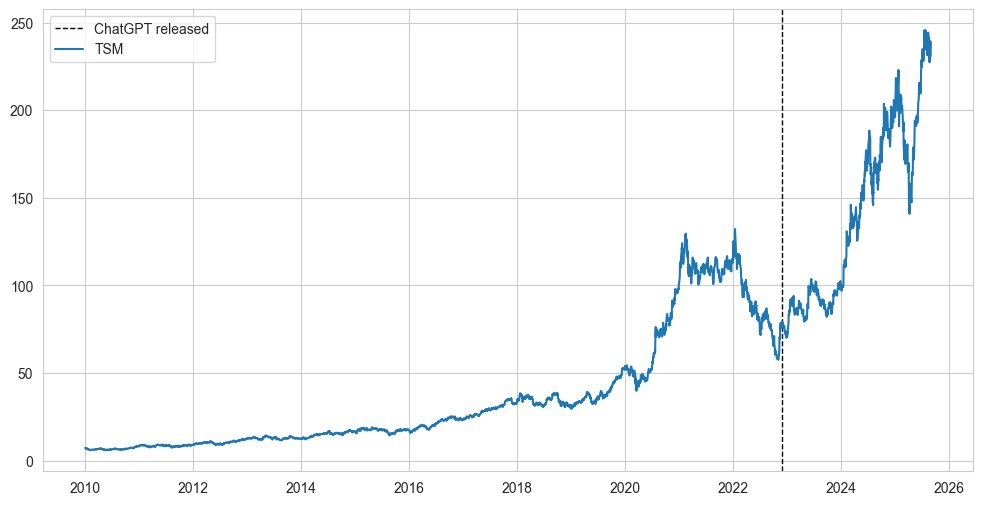

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_style(style="whitegrid")

plt.figure(figsize=(12, 6))
plt.axvline(x=pd.to_datetime("2022-11-30"), ls='--', color="black", label="ChatGPT released", lw=1)
plt.plot(df["TSM"], label="TSM")
plt.legend()
plt.show()

If there was small but constant changes from 2010 to 2018, after the signal gets more amplitude.

## PSI Index

We will implement the PSI Index, as there is no gold standard industry function (as of our knowledge). The first function `compute_psi` will compute the PSI Index only for one indicator, then a second function `compute_psi_df` will loop over all the columns in a dataset.

In [ ]:
import numpy as np
from scipy.stats import entropy

def compute_psi(train, test, n_bins=10, epsilon=1e-6):
    train = np.asarray(train)
    test = np.asarray(test)
    bin_edges = np.histogram_bin_edges(train, bins=n_bins)

    train_counts, _ = np.histogram(train, bins=bin_edges)
    test_counts, _ = np.histogram(test, bins=bin_edges)
    train_pct = train_counts / len(train)
    test_pct = test_counts / len(test)

    train_pct = np.clip(train_pct, epsilon, None)
    test_pct = np.clip(test_pct, epsilon, None)

    psi = entropy(train_pct, test_pct) + entropy(test_pct, train_pct)

    return psi




def compute_psi_df(X_train: pd.DataFrame, X_test: pd.DataFrame, n_bins=10) -> pd.Series:
    common_cols = [c for c in X_train.columns if c in X_test.columns]
    psi_values = {
        col: compute_psi(X_train[col].dropna(), X_test[col].dropna(), n_bins=n_bins)
        for col in common_cols
    }
    return pd.Series(psi_values, name="PSI").sort_values(ascending=False)

We now need to split the dataset in two with respect to the date of the trade, then compute the PSI Index.

In [18]:
def train_test_time_splitting(X, y, train_ratio=0.75):
    index = int(df.shape[0] * train_ratio)
    X_train, y_train = X.iloc[:index], y[:index]
    X_test, y_test = X.iloc[index:], y[index:]
    return X_train, X_test, y_train, y_test


ticker = "TSM"
columns = ["NVDA", "MU", "Gold"]
X = df[columns]
y = df[ticker]

X_train, X_test, y_train, y_test = train_test_time_splitting(X, y)

PSI = compute_psi_df(X_train, X_test)
print(PSI)

NVDA    8.567778
MU      7.418121
Gold    6.779476
Name: PSI, dtype: float64


We can also visualize the the results with the following function :

In [ ]:
def display_psi(psi_series: pd.Series, warning_th=0.1, drift_th=0.2):
    colors = [
        "tab:red" if value >= drift_th else "tab:orange" if value >= warning_th else "tab:green"
        for value in psi_series
    ]

    fig, ax = plt.subplots(figsize=(7, 0.5 * len(psi_series) + 1.5))
    bars = ax.barh(psi_series.index[::-1], psi_series.values[::-1], color=colors[::-1])

    ax.axvline(warning_th, color="tab:orange", linestyle="--", linewidth=1)
    ax.axvline(drift_th, color="tab:red", linestyle="--", linewidth=1)
    ax.text(warning_th, len(psi_series) - 0.5, "warning", color="tab:orange",
             fontsize=9, ha="right", va="bottom")
    ax.text(drift_th, len(psi_series) - 0.5, "drift", color="tab:red",
             fontsize=9, ha="left", va="bottom")

    for bar, value in zip(bars, psi_series.values[::-1]):
        ax.text(bar.get_width() + 0.01 * psi_series.max(), bar.get_y() + bar.get_height() / 2,
                 f"{value:.3f}", va="center", fontsize=9)

    ax.set_xlabel("PSI")
    ax.set_title("Population Stability Index by feature")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    fig.tight_layout()
    plt.show()

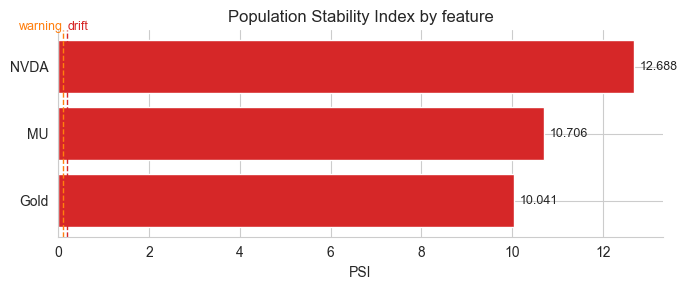

In [14]:
display_psi(PSI)